In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df=pd.read_csv('data/google_cleaned.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Month,Year,Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,1,2018,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,1,2018,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8,2018,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,6,2018,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,6,2018,20


In [3]:
df.duplicated('App').sum() 

np.int64(1181)

In [4]:
df.drop_duplicates(subset='App',keep='first',inplace=True)

In [5]:
df.shape

(9659, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 0 to 10839
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Last Updated    9659 non-null   str    
 11  Current Ver     9651 non-null   str    
 12  Android Ver     9657 non-null   str    
 13  Month           9659 non-null   int64  
 14  Year            9659 non-null   int64  
 15  Day             9659 non-null   int64  
dtypes: float64(3), int64(5), str(8)
memory usage: 1.3 MB


### explore data

In [7]:
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()
## print column 
print('We have {} numerical features:{}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features:{}'.format(len(categorical_features),categorical_features))

We have 8 numerical features:['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Month', 'Year', 'Day']
We have 8 categorical features:['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [8]:
### proportion of count daat on categoriucal data

for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)

App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872036
LIFESTYLE       

C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2667601154.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df[numeric_features[i]],shade=True,color='r')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2667601154.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df[numeric_features[i]],shade=True,color='r')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2667601154.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df[numeric_features[i]],shade=True,color='r')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2667601154.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`

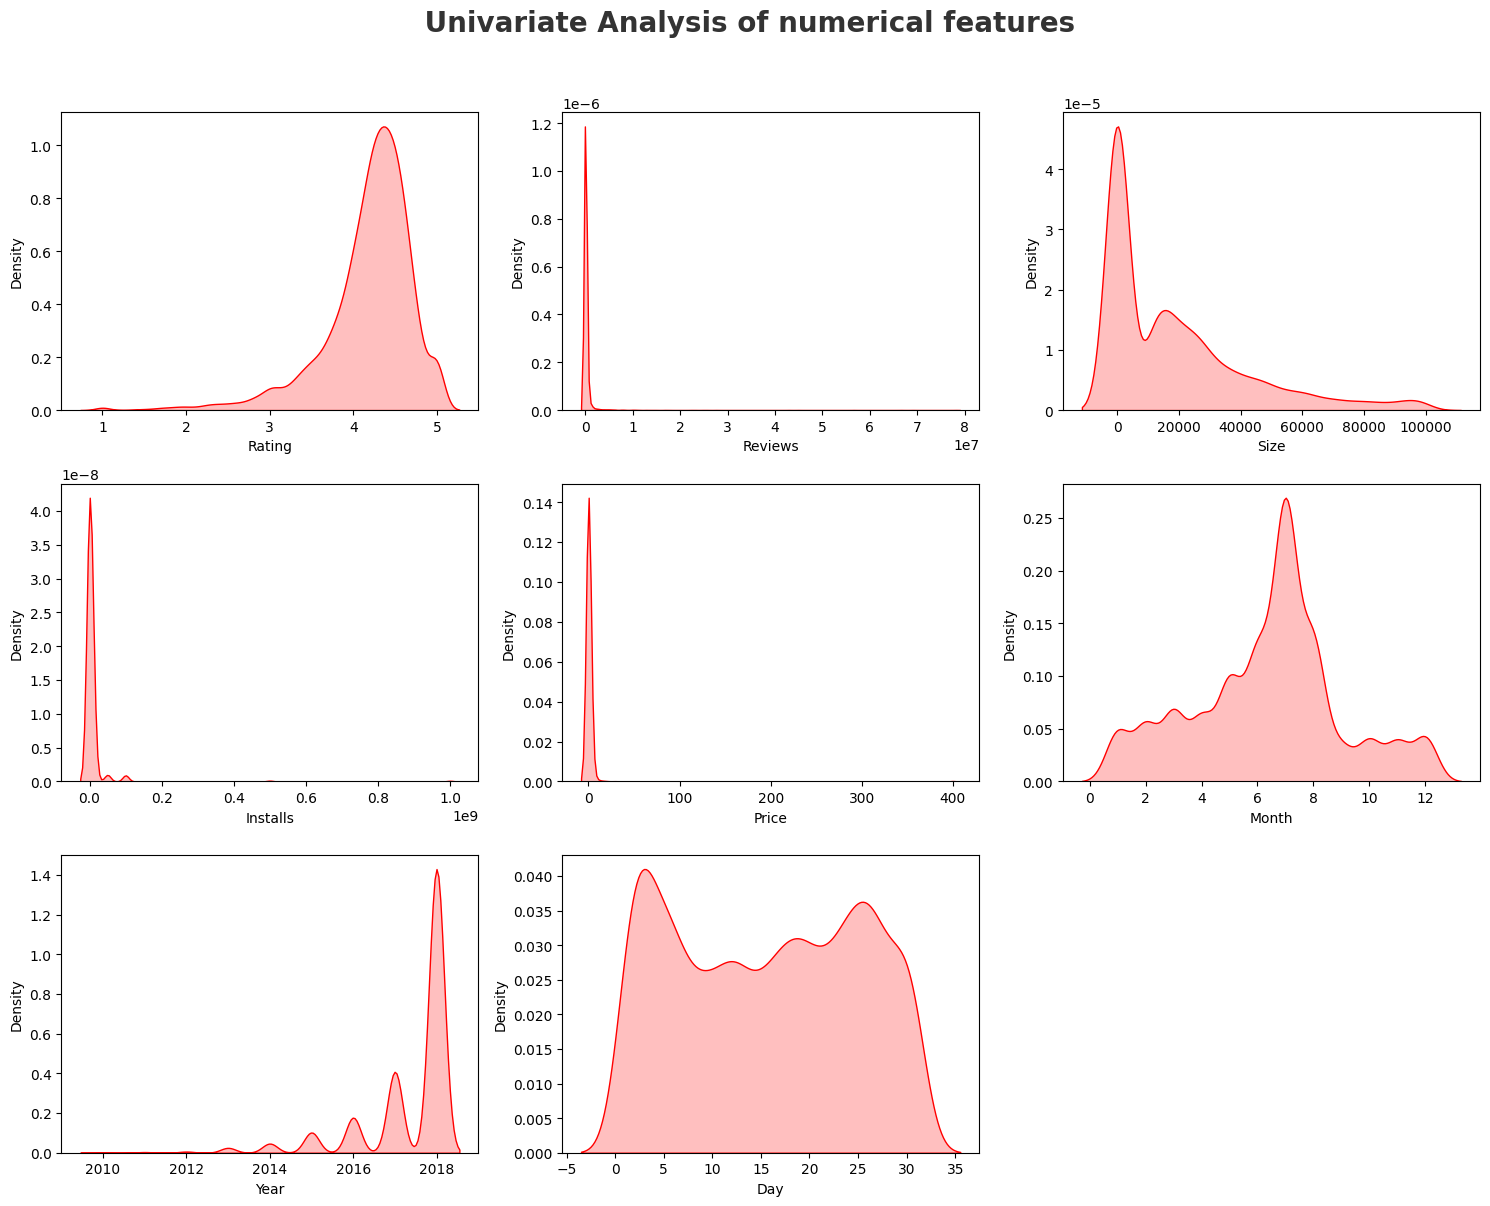

In [9]:
## proportion of count dataon numerical column
plt.figure(figsize=(15,15))
plt.suptitle(' Univariate Analysis of numerical features',fontsize=20,fontweight='bold',alpha=0.8,y=1.02)

for i in range(0,len(numeric_features)):
    plt.subplot(4,3,i+1)
    sns.kdeplot(x=df[numeric_features[i]],shade=True,color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [10]:
### observations
## rating and year is left skewed
## reviews,installs,size and price is right skewed

C:\Users\preet\AppData\Local\Temp\ipykernel_7336\776799445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[category[i]],palette='Set2')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\776799445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[category[i]],palette='Set2')


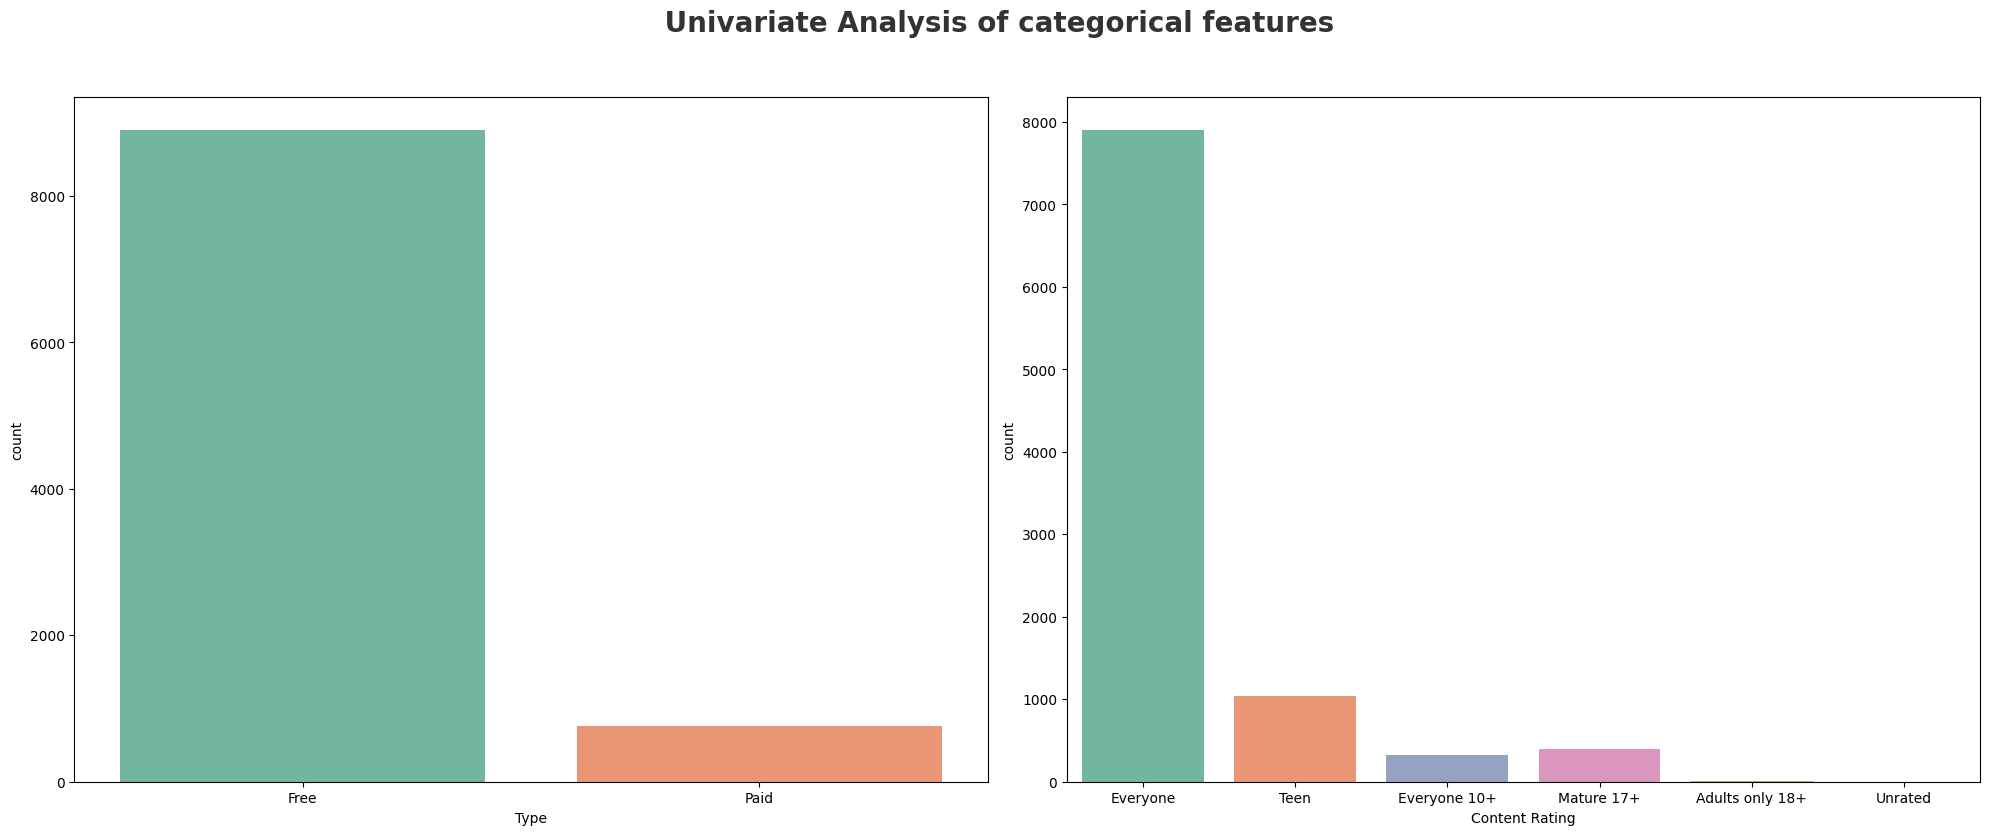

In [11]:
plt.figure(figsize=(20,15))
plt.suptitle(' Univariate Analysis of categorical features',fontsize=20,fontweight='bold',alpha=0.8,y=1.02)
category=['Type','Content Rating']
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[category[i]],palette='Set2')
    plt.xlabel(category[i])
    plt.tight_layout()

In [12]:
## which is popular app category

df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Month,Year,Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,1,2018,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,1,2018,15


<Axes: >

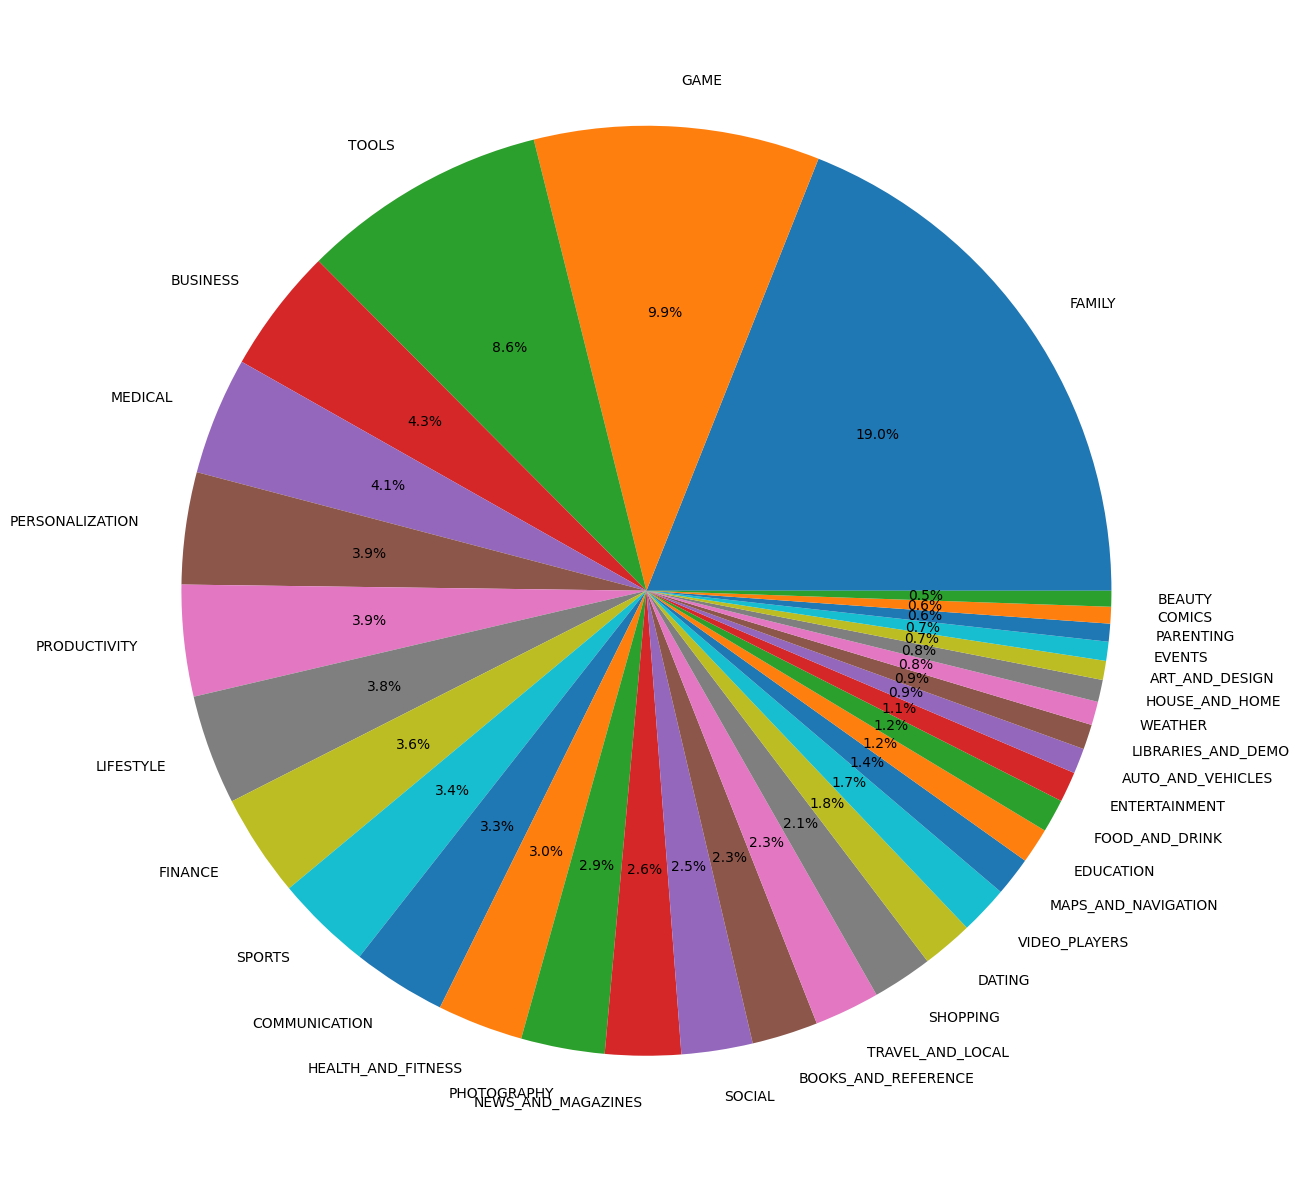

In [13]:
df['Category'].value_counts().plot.pie(figsize=(15,16),autopct='%1.1f%%')

In [14]:
### more kind of apps in playstore under category family agme and tools 
## beauty education and events are very less

category=pd.DataFrame(df['Category'].value_counts())
category.rename(columns={'Category':'Count'},inplace=True)


In [15]:
category

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


C:\Users\preet\AppData\Local\Temp\ipykernel_7336\3840469141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category.head(10).index,


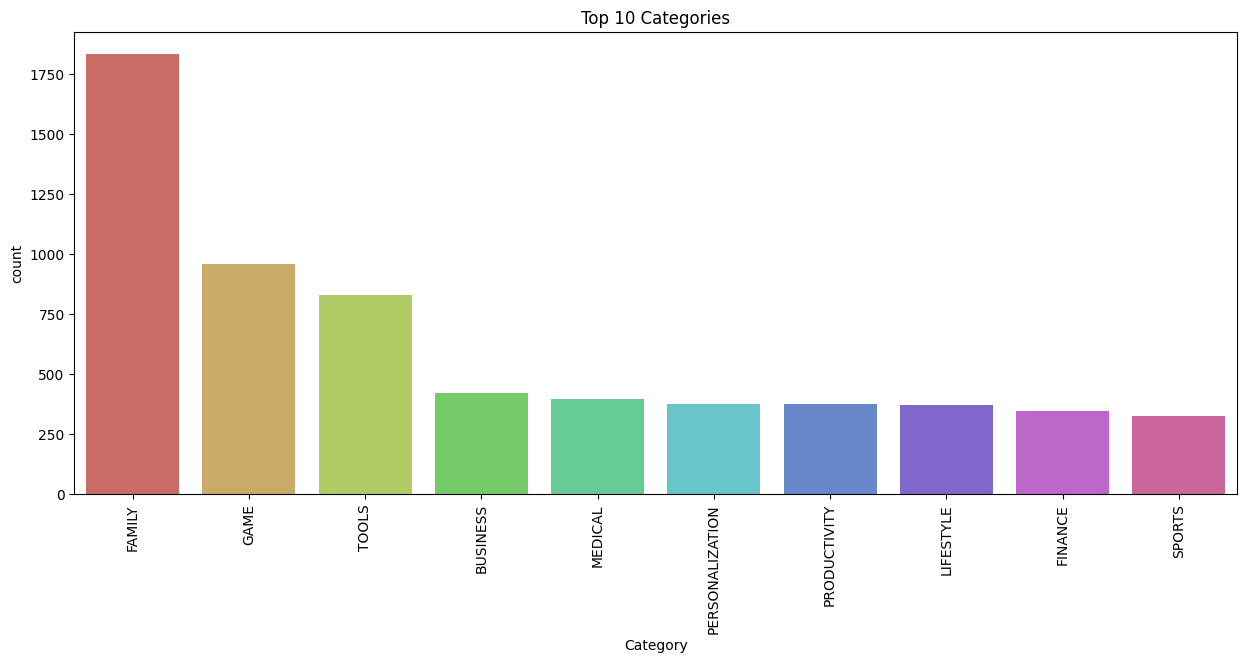

In [16]:
plt.figure(figsize=(15,6))

sns.barplot(x=category.head(10).index,
            y=category.head(10)['count'],
            palette='hls')

plt.title('Top 10 Categories')
plt.xticks(rotation=90)
plt.show()

C:\Users\preet\AppData\Local\Temp\ipykernel_7336\405381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Installs' , y = 'Category' , data = df2,palette='Set2' )


Text(0.5, 1.0, 'Most Popular Categories in Play Store')

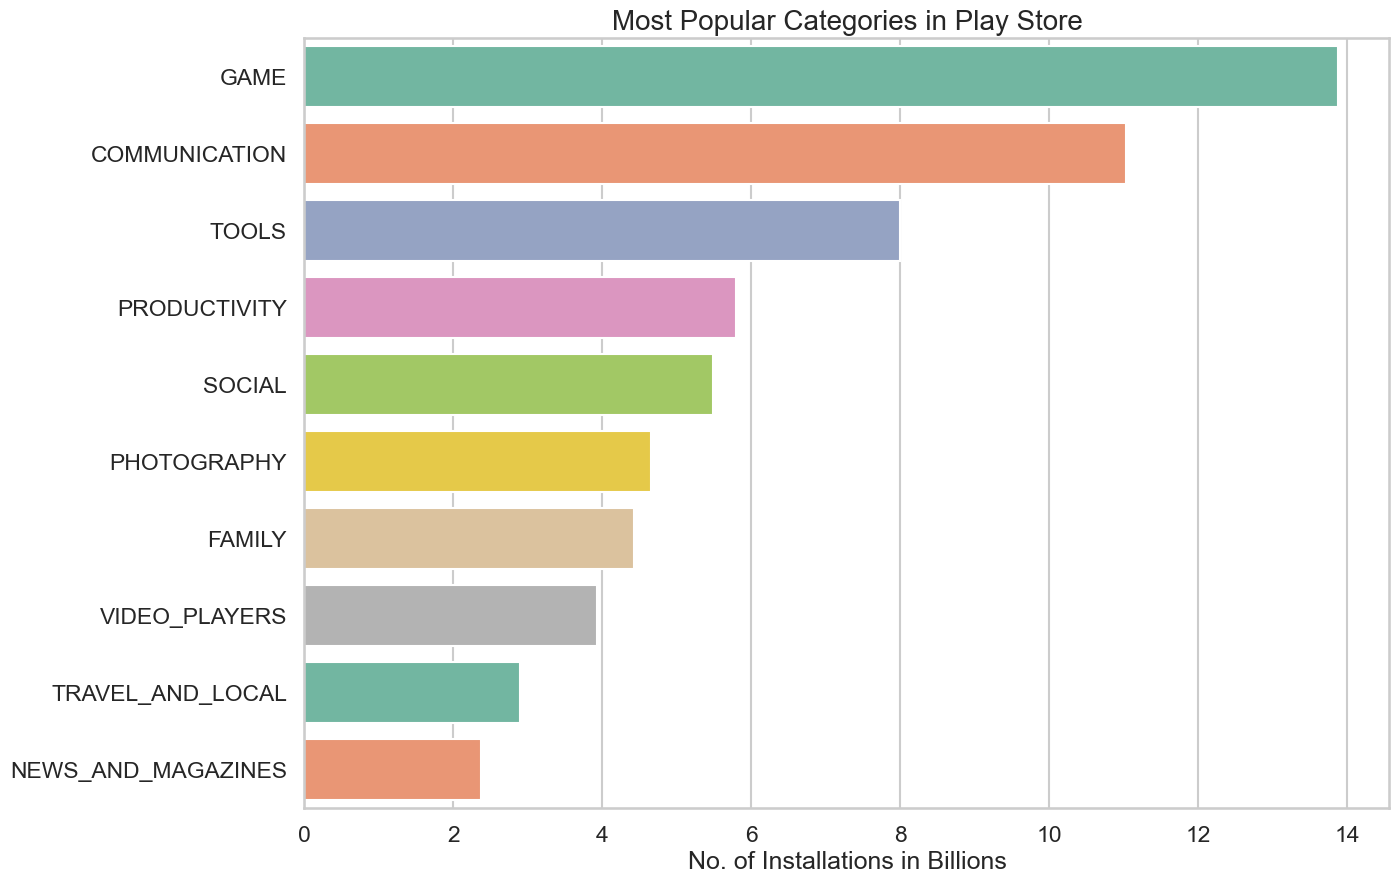

In [ ]:
## which catgeory has largest number of installation
category_installed=df.groupby(df['Category'])['Installs'].sum().sort_values(ascending = False).reset_index()
category_installed.Installs = category_installed.Installs/1000000000
df2 = category_installed.head(10)
plt.figure(figsize = (14,10))
sns.set_context("talk")
sns.set_style("whitegrid")

ax = sns.barplot(x = 'Installs' , y = 'Category' , data = df2,palette='Set2' )
ax.set_xlabel('No. of Installations in Billions')
ax.set_ylabel('')
ax.set_title("Most Popular Categories in Play Store", size = 20)


C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2790096182.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df3,x= 'Installs' ,y='App',palette='Set2')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2790096182.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df3,x= 'Installs' ,y='App',palette='Set2')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2790096182.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df3,x= 'Installs' ,y='App',palette='Set2')
C:\Users\preet\AppData\Local\Temp\ipykernel_7336\2790096182.p

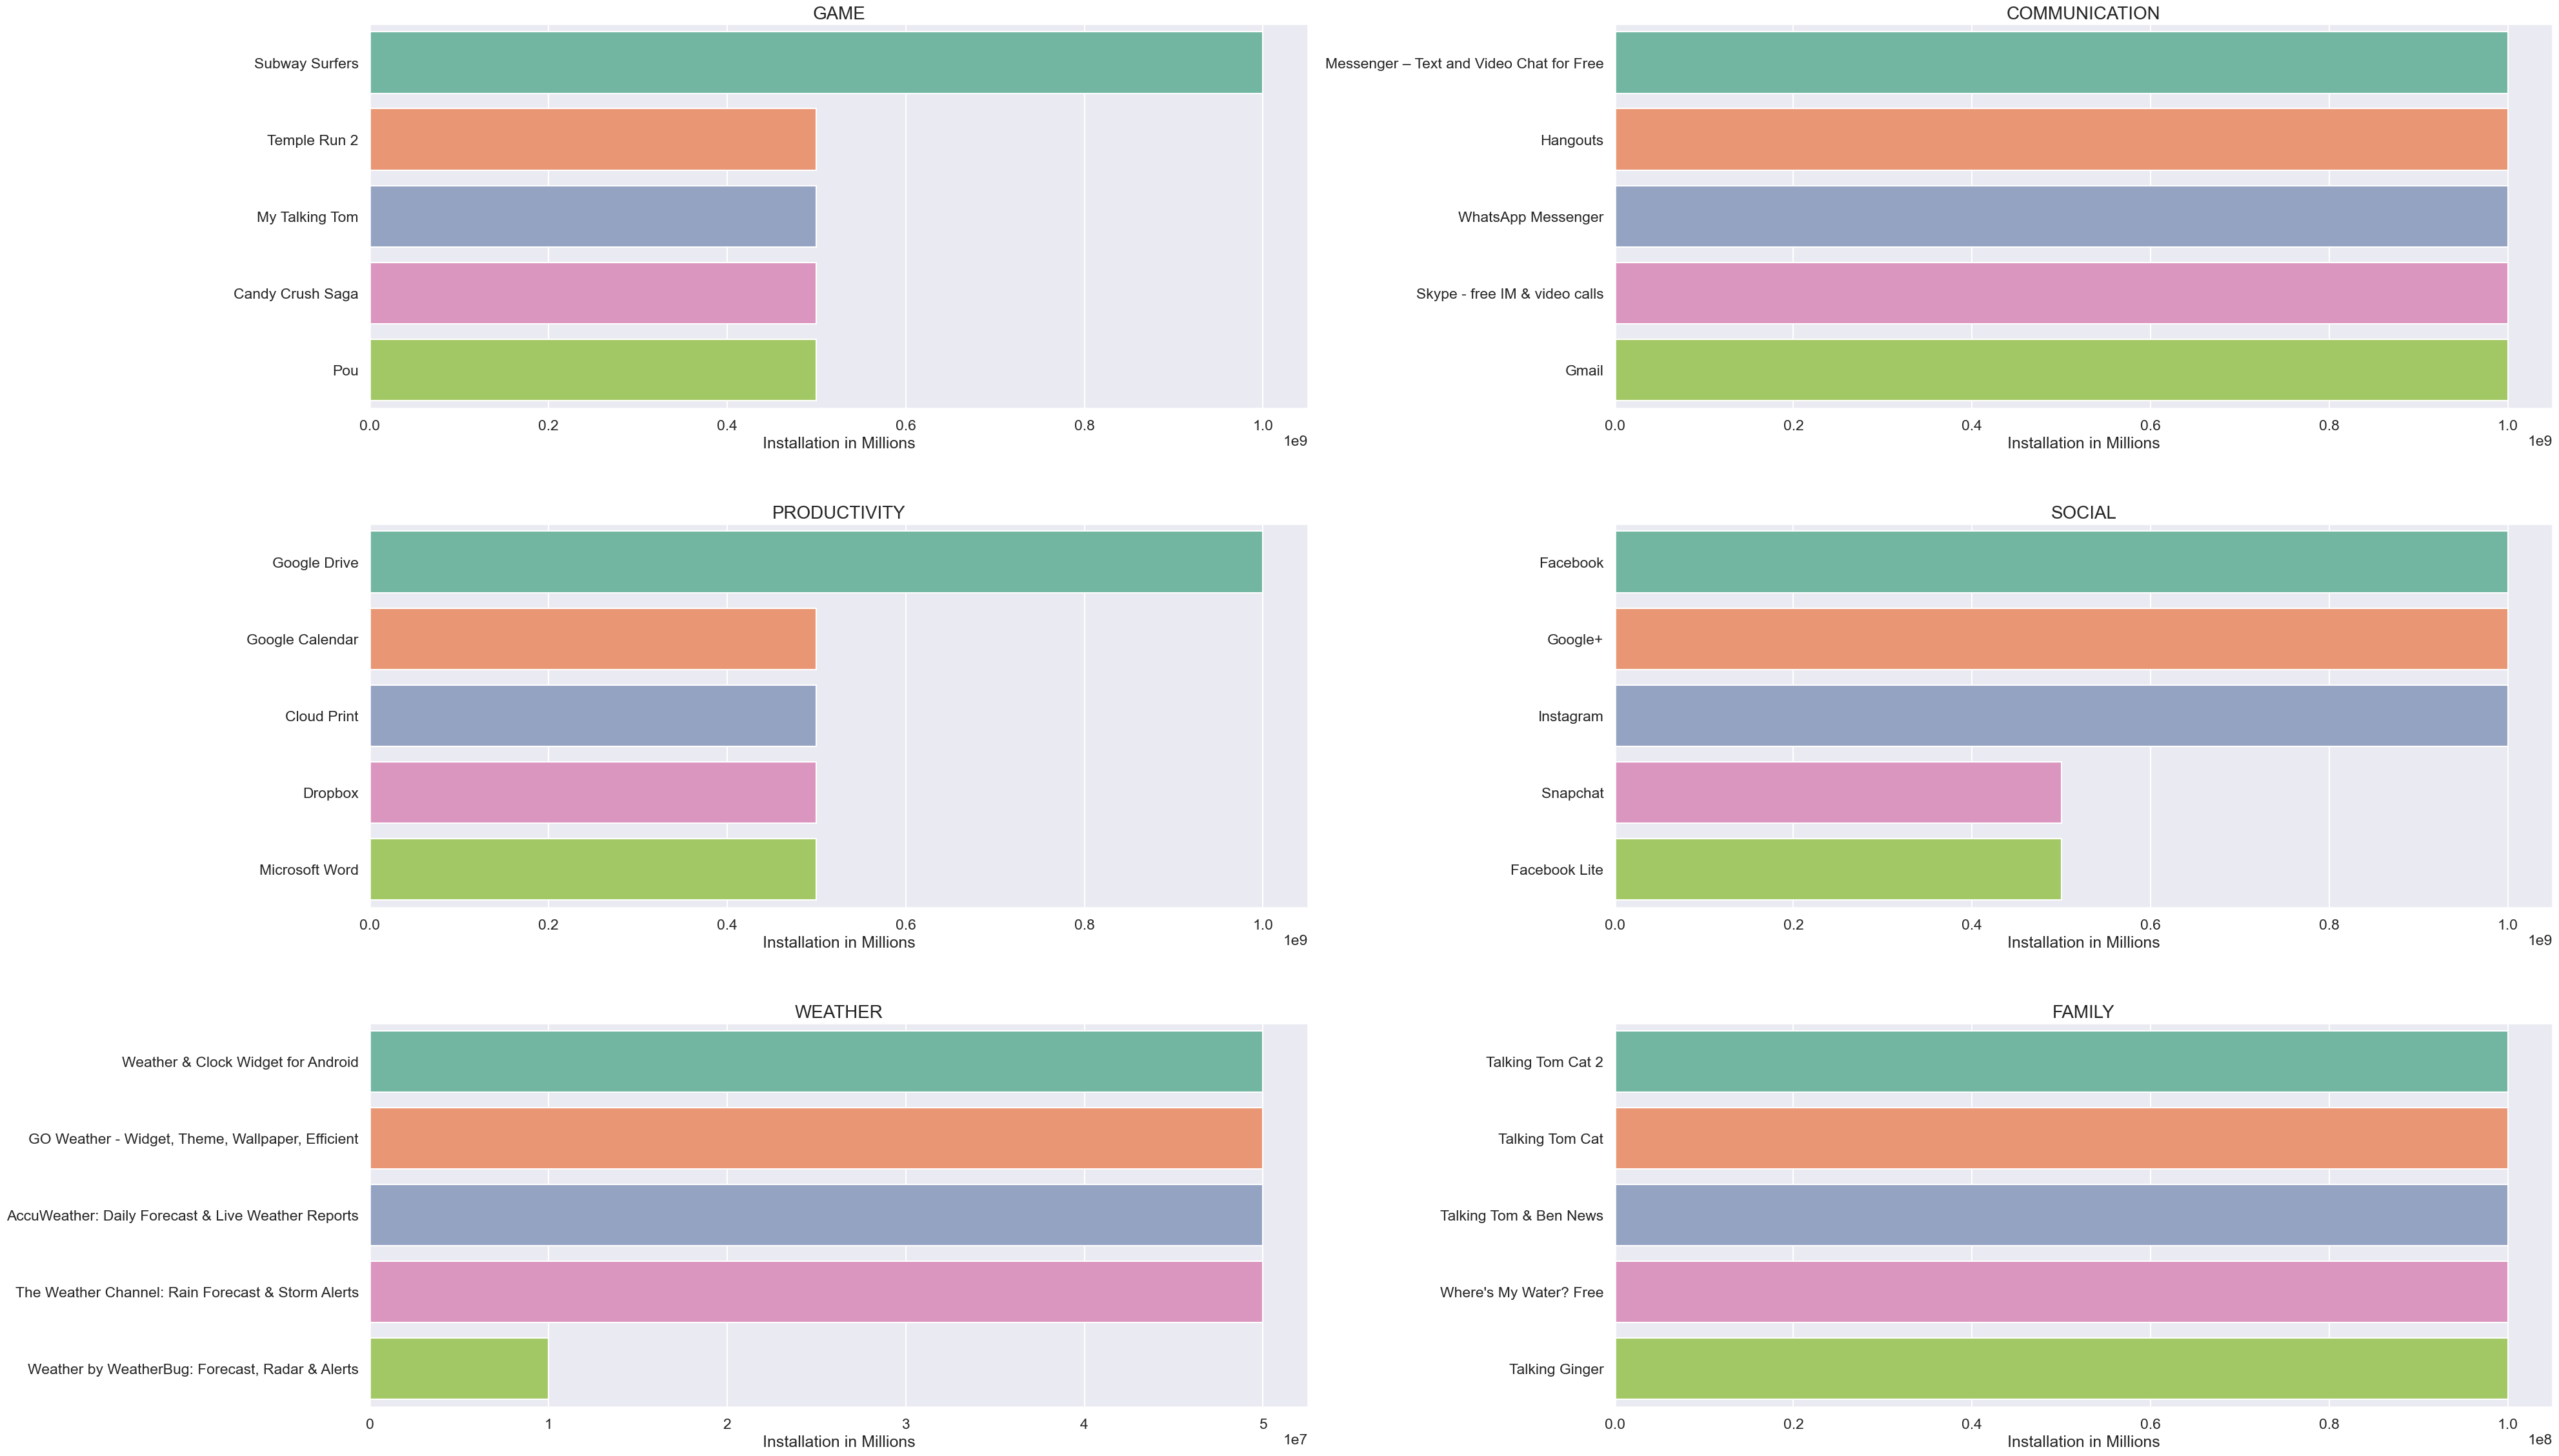

In [45]:
dfa=df.groupby(['Category','App'])['Installs'].sum().reset_index()
dfa = dfa.sort_values('Installs', ascending = False)
apps = ['GAME', 'COMMUNICATION', 'PRODUCTIVITY', 'SOCIAL' ,'WEATHER','FAMILY']

sns.set_context("talk")
sns.set_style("darkgrid")
plt.figure(figsize=(40,30))


for i,app in enumerate(apps):
    df2 = dfa[dfa.Category == app]
    df3 = df2.head(5)
    plt.subplot(4,2,i+1)
    sns.barplot(data= df3,x= 'Installs' ,y='App',palette='Set2')
    plt.xlabel('Installation in Millions')
    plt.ylabel('')
    plt.title(app,size = 20)


plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()
    


In [44]:
rating = df.groupby(['Category','Installs', 'App'])['Rating'].sum().sort_values(ascending = False).reset_index()
toprating_apps = rating[rating.Rating == 5.0]
print("Number of 5 rated apps",toprating_apps.shape[0])
toprating_apps.head(1)

Number of 5 rated apps 271


,Category,Installs,App,Rating
0,FAMILY,10,USMLE Step 2 CK Flashcards,5.0
